<a href="https://colab.research.google.com/github/adipriya157/DRP-Project-on-RL/blob/main/btc_market_making_dqn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("martinsn/high-frequency-crypto-limit-order-book-data")

print("Path to dataset files:", path)

100%|██████████| 993M/993M [00:12<00:00, 85.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/martinsn/high-frequency-crypto-limit-order-book-data/versions/1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
import os
os.listdir(path)

['ETH_1min.csv',
 'ADA_5min.csv',
 'ADA_1sec.csv',
 'BTC_5min.csv',
 'ADA_1min.csv',
 'ETH_5min.csv',
 'BTC_1sec.csv',
 'BTC_1min.csv',
 'ETH_1sec.csv']

In [4]:
df = pd.read_csv(os.path.join(path, "BTC_1sec.csv")) #if this doesn't work, yall can find the path
#df.head()

if np.sum(df.isnull().any()) > 0:
    raise Exception("null values detected") #before we add in NA from windows, check
#seems that if no volume exists for a level it is cast to 0, idk



In [5]:
df["date"] = pd.to_datetime(df["system_time"])
#trades go on 24/7, so could normalize by day or by rolling window of last observations (except for first day, which I normalize to day 0)
#everything is in april but we can be more careful.
#I imagine for not having to recompute everything we would just use half day intervals or something as we have latency?

df["date"].head()
df["trading_day"] = df["date"].dt.dayofyear - np.min(df["date"].dt.dayofyear)
#df["trading_day"].head()

In [6]:
#construct rolling volatility for midprice (or volatility per day?) 24 hours * 3600 seconds = 1 day and df is per second
window = 24 * 3600

df["log_midprice"] = np.log(df["midpoint"] / df["midpoint"].shift(1))
df["rolling_midprice_vol"] = df["log_midprice"].rolling(window = window).std()
#I don't need to annualize this or make it weighted to daily std?
#TODO if I made index time I could use timedelta to be sure.



In [7]:
#weighted midprice? (from stack exchange)

# The definition of micro-price is
# S = Pa * Vb / (Va + Vb) + Pb * Va / (Va + Vb)
# where Pa is the ask price, Va is the ask volume, Pb is the bid price, and Vb is the bid volume.
#for speed I compute the best ask price, perhaps I weight the other distances???
#should I just add all of the volumes for the 1 level lmao
#also, for computing Va do I add the market/limits or just the limits?

df["asks_price_0"] = df["midpoint"] * (1 + df["asks_distance_0"])
df["bids_price_0"] = df["midpoint"] * (1 + df["bids_distance_0"])
df["microprice_0"] = ( (df["asks_price_0"] * df["asks_limit_notional_0"]
                      + df["bids_price_0"] * df["bids_limit_notional_0"]) /
                      (df["asks_limit_notional_0"] + df["bids_limit_notional_0"]))

#sanity check that bids/asks match spreads.
if np.sum(~np.isclose(df["asks_price_0"] - df["bids_price_0"], df["spread"], rtol = 1e-5)) > 0:
          raise Exception("spread doesn't match asks/bids")




In [8]:
#make ema of midpoint and microprice

# Exponential Moving Average (EMA)
window = 180 #180 seconds, i.e., 3 minutes. can be changed.

df['ema_microprice_0'] = df["microprice_0"].ewm(span = window).mean()
df['ema_midpoint'] = df['midpoint'].ewm(span = window).mean()
#df[["ema_microprice_0", "microprice_0"]][2000:2010] #is a sanity check to ensure column not overwritten

In [9]:
#percent changes of midpoint
df["midpoint_pct_change"] = df["midpoint"].pct_change()

In [10]:
#create relative spreads up to bid/ask level n.
#because they are all percents of the midprice,
n = 5
numer = 0
denom = 0
for i in range(1,n+1):
    numer += df["asks_distance_" + str(i)] - df["bids_distance_" + str(i)]
    denom += 2 + df["asks_distance_" + str(i)] - df["bids_distance_" + str(i)]
df["rel_spread_"+str(n)] = numer / denom

In [11]:
#create total volume for the first n levels
n = 15
df["asks_limit_volume"] = df["asks_limit_notional_0"] * 0
df["bids_limit_volume"] = df["bids_limit_notional_0"] * 0
for i in range(n):
    df["asks_limit_volume"] += df["asks_limit_notional_" + str(i)]
    df["bids_limit_volume"] += df["bids_limit_notional_" + str(i)]

In [12]:
#finally, make a couple of different normalizing functions
'''
given list of columns, computes the normalized features per day based on mean, std of previous day (half day? hour?)
df: a dataframe requiring a datetime or date column.
columns: a list of column names

returns: a list of the new columns created.
'''
def normalize_per_day(df, columns): #pass by reference intensifies, unless we wish to make a new dataframe
    if "date" not in df.columns:
        raise Exception("no date")
    #if we want to do this in place, reverse loop order. averages over previous day
    new_columns = []
    for column in columns:
        if column not in df.columns:
            raise Exception("You have selected a column, " + column + " not in the dataframe")
            #TODO clean up by removing the columns not in columns

        for day in range(1, len(df["trading_day"].unique())):
            prev_mean = np.mean(df[column][df["trading_day"] == day - 1])
            prev_std = np.std(df[column][df["trading_day"] == day - 1])
            df.loc[df["trading_day"] == day, column + "_norm"] = (df[column][df["trading_day"] == day] - prev_mean) / prev_std
        df.loc[df["trading_day"] == 0, column + "_norm"] = np.nan
        new_columns.append(column + "_norm")
    return new_columns
#normalize_per_day(df, ["midpoint"])
#print(df["midpoint_norm"])


'''
given list of columns, computes the normalized features from rolling average of last couple observations (seconds)

df: a dataframe requiring a datetime or date column.
columns: a list of column names
window: number of seconds the rolling window looks back.

returns: a list of the new columns created.
TODO should I name the columns to refer to the window used?
'''
def normalize_last_observs(df, columns, window = 20): #in seconds, could modify to time delta
    new_columns = []
    for column in columns:
        df[column + "_norm"] = ((df[column] - df[column].rolling(window = window).mean()) /
                                (df[column].rolling(window = window).std() + 1e-8)) #stability
        new_columns.append(column + "_norm")
    return new_columns



In [13]:
cols_to_normalize = []
levels_to_keep = 5
["bids_distance_" + str(i) for i in range(5)]
for i in range(5+1):
    cols_to_normalize.append("bids_distance_" + str(i))
    cols_to_normalize.append("asks_distance_" + str(i))

cols_to_normalize.append("midpoint") #idk about this one, shrugs
cols_to_normalize.append("midpoint_pct_change")
cols_to_normalize.append("asks_limit_volume")
cols_to_normalize.append("bids_limit_volume")

new_columns = normalize_last_observs(df, cols_to_normalize, 3600*6) #quarter of a day, idk

In [14]:
columns_to_keep = []
columns_to_keep = new_columns
columns_to_keep + ["midpoint", "ema_midpoint",
                    "microprice", "ema_microprice_0",
                    "rolling_midprice_vol", "date"]
for i in range(5):
    columns_to_keep.append("bids_distance_"+str(i))
    columns_to_keep.append("asks_distance_"+str(i))
    columns_to_keep.append("asks_limit_notional_"+str(i))
    columns_to_keep.append("bids_limit_notional_"+str(i))

# Find columns to drop
columns_to_drop = df.columns.difference(columns_to_keep)

# Drop the columns not in the keep list
df = df.drop(columns=columns_to_drop)



In [15]:
df.to_csv("btc_1s_normed_features.csv")

In [16]:
# --- You can choose which columns are in the state space ---
feature_cols = [
    # core prices / signals
    "midpoint",
    "ema_midpoint",
    "microprice_0",
    "ema_microprice_0",
    "rolling_midprice_vol",

    # LOB pressure (a few levels)
    "asks_distance_0", "bids_distance_0",
    "asks_distance_1", "bids_distance_1",
    "asks_distance_2", "bids_distance_2",

    # LOB size / depth (a few levels)
    "asks_limit_notional_0", "bids_limit_notional_0",
    "asks_limit_notional_1", "bids_limit_notional_1",
]

# Normalisation if desired
norm_cols = [c for c in df.columns if c.endswith("_norm")]
feature_cols = list(dict.fromkeys(feature_cols + norm_cols))  # dedupe, keep order

#df = df.dropna(subset=feature_cols).reset_index(drop=True)

In [17]:
import numpy as np
from collections import deque
import gymnasium as gym
from gymnasium import spaces

class BTCMarketMakingEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(
        self,
        df,
        feature_cols,
        lookback=30,
        episode_len=3600,
        tick_size=0.5,
        offset_choices=(0, 1, 2, 4, 8),
        size_choices=(0.0, 0.001, 0.002, 0.005),
        fee_bps=1.0,               # transaction cost per trade if required
        inventory_limit=0.02,      # max abs inventory allowed
        gamma_step=None,           # if set (e.g., 0.999), reward_t *= gamma_step**t
        seed=None,
    ):
        super().__init__()
        self.df = df
        self.feature_cols = feature_cols
        self.lookback = int(lookback)
        self.episode_len = int(episode_len)

        self.tick_size = float(tick_size)
        self.offset_choices = np.array(offset_choices, dtype=np.int32)
        self.size_choices = np.array(size_choices, dtype=np.float32)

        self.fee_bps = float(fee_bps)
        self.inventory_limit = float(inventory_limit)
        self.gamma_step = gamma_step

        self.n_features = len(feature_cols)


        # [bid1_offset, bid1_size, bid2_offset, bid2_size, ask1_offset, ask1_size, ask2_offset, ask2_size]
        self.action_space = spaces.MultiDiscrete([
            len(self.offset_choices), len(self.size_choices),
            len(self.offset_choices), len(self.size_choices),
            len(self.offset_choices), len(self.size_choices),
            len(self.offset_choices), len(self.size_choices),
        ])


        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.lookback * self.n_features,), dtype=np.float32
        )

        self._rng = np.random.default_rng(seed)
        self._buf = deque(maxlen=self.lookback)

        # internal episode state
        self.t0 = None
        self.t = None
        self.steps = None
        self.cash = None
        self.inv = None
        self.prev_wealth = None

    def _best_bid_ask(self, row):
        mid = float(row["midpoint"])
        best_ask = mid * (1.0 + float(row["asks_distance_0"]))
        best_bid = mid * (1.0 + float(row["bids_distance_0"]))
        return best_bid, best_ask, mid

    def _wealth(self, mid):
        return self.cash + self.inv * mid

    def _get_obs(self):
        # If buffer not full, pad with first element
        if len(self._buf) < self.lookback:
            first = self._buf[0]
            while len(self._buf) < self.lookback:
                self._buf.appendleft(first)
        obs = np.concatenate(list(self._buf), axis=0).astype(np.float32)
        return obs

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        # pick a random start
        max_start = len(self.df) - (self.episode_len + 2)
        self.t0 = int(self._rng.integers(low=self.lookback, high=max_start))
        self.t = self.t0
        self.steps = 0

        self.cash = 0.0
        self.inv = 0.0

        # init buffer
        self._buf.clear()
        for k in range(self.lookback):
            r = self.df.iloc[self.t - (self.lookback - 1 - k)]
            self._buf.append(np.array(r[self.feature_cols].values, dtype=np.float32))

        _, _, mid = self._best_bid_ask(self.df.iloc[self.t])
        self.prev_wealth = self._wealth(mid)

        return self._get_obs(), {}

    def step(self, action):
        action = np.asarray(action, dtype=np.int32)
        row = self.df.iloc[self.t]
        next_row = self.df.iloc[self.t + 1]

        best_bid, best_ask, mid = self._best_bid_ask(row)
        _, _, next_mid = self._best_bid_ask(next_row)

        # decode action
        b1_off = self.offset_choices[action[0]]
        b1_sz  = float(self.size_choices[action[1]])
        b2_off = self.offset_choices[action[2]]
        b2_sz  = float(self.size_choices[action[3]])
        a1_off = self.offset_choices[action[4]]
        a1_sz  = float(self.size_choices[action[5]])
        a2_off = self.offset_choices[action[6]]
        a2_sz  = float(self.size_choices[action[7]])

        bid_quotes = sorted([(b1_off, b1_sz), (b2_off, b2_sz)], key=lambda x: x[0])
        ask_quotes = sorted([(a1_off, a1_sz), (a2_off, a2_sz)], key=lambda x: x[0])

        # Simulate fills based on next_mid crossing quote price
        fee_mult = self.fee_bps * 1e-4

        # BUY fills
        for off, sz in bid_quotes:
            if sz <= 0:
                continue
            px = best_bid - off * self.tick_size
            if next_mid <= px and abs(self.inv + sz) <= self.inventory_limit:
                cost = px * sz
                fee = cost * fee_mult
                self.cash -= (cost + fee)
                self.inv += sz

        # SELL fills
        for off, sz in ask_quotes:
            if sz <= 0:
                continue
            px = best_ask + off * self.tick_size
            if next_mid >= px and abs(self.inv - sz) <= self.inventory_limit:
                proceeds = px * sz
                fee = proceeds * fee_mult
                self.cash += (proceeds - fee)
                self.inv -= sz

        # advance time, update buffer
        self.t += 1
        self.steps += 1
        self._buf.append(np.array(next_row[self.feature_cols].values, dtype=np.float32))

        # reward = delta wealth
        wealth = self._wealth(next_mid)
        reward = wealth - self.prev_wealth
        self.prev_wealth = wealth

        # optional per-step discounting so total sum finite even if episodes are long
        if self.gamma_step is not None:
            reward = reward * (self.gamma_step ** (self.steps - 1))

        terminated = False
        truncated = (self.steps >= self.episode_len)

        info = {
            "mid": next_mid,
            "cash": self.cash,
            "inventory": self.inv,
            "wealth": wealth,
        }

        return self._get_obs(), float(reward), terminated, truncated, info

In [18]:
# Install RL dependencies (run this once)
%pip install -q stable-baselines3 gymnasium torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 11.6 MB/s eta 0:00:00


In [19]:
# Repair df after the bad column-drop cell

# Rebuild essential columns if missing
if "midpoint" not in df.columns:
    # easiest recovery: reload raw file and reconstruct features
    import os
    import numpy as np
    import pandas as pd

    raw_df = pd.read_csv(os.path.join(path, "BTC_1sec.csv"))
    raw_df["date"] = pd.to_datetime(raw_df["system_time"])
    raw_df["trading_day"] = raw_df["date"].dt.dayofyear - np.min(raw_df["date"].dt.dayofyear)

    window = 24 * 3600
    raw_df["log_midprice"] = np.log(raw_df["midpoint"] / raw_df["midpoint"].shift(1))
    raw_df["rolling_midprice_vol"] = raw_df["log_midprice"].rolling(window=window).std()

    raw_df["asks_price_0"] = raw_df["midpoint"] * (1 + raw_df["asks_distance_0"])
    raw_df["bids_price_0"] = raw_df["midpoint"] * (1 + raw_df["bids_distance_0"])
    raw_df["microprice_0"] = (
        raw_df["asks_price_0"] * raw_df["asks_limit_notional_0"]
        + raw_df["bids_price_0"] * raw_df["bids_limit_notional_0"]
    ) / (raw_df["asks_limit_notional_0"] + raw_df["bids_limit_notional_0"] + 1e-8)

    ema_window = 180
    raw_df["ema_microprice_0"] = raw_df["microprice_0"].ewm(span=ema_window).mean()
    raw_df["ema_midpoint"] = raw_df["midpoint"].ewm(span=ema_window).mean()
    raw_df["midpoint_pct_change"] = raw_df["midpoint"].pct_change()

    n = 15
    raw_df["asks_limit_volume"] = 0.0
    raw_df["bids_limit_volume"] = 0.0
    for i in range(n):
        raw_df["asks_limit_volume"] += raw_df[f"asks_limit_notional_{i}"]
        raw_df["bids_limit_volume"] += raw_df[f"bids_limit_notional_{i}"]

    # preserve normalized cols from current df if they exist and lengths match
    norm_cols_existing = [c for c in df.columns if c.endswith("_norm")]
    if len(df) == len(raw_df):
        for c in norm_cols_existing:
            raw_df[c] = df[c].values

    df = raw_df.copy()

print("midpoint in df:", "midpoint" in df.columns)
print("microprice_0 in df:", "microprice_0" in df.columns)
print("df shape:", df.shape)

midpoint in df: True
microprice_0 in df: True
df shape: (1030728, 184)


In [20]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

feature_cols = [
    "midpoint",
    "ema_midpoint",
    "microprice_0",
    "ema_microprice_0",
    "rolling_midprice_vol",
    "asks_distance_0", "bids_distance_0",
    "asks_distance_1", "bids_distance_1",
    "asks_distance_2", "bids_distance_2",
    "asks_limit_notional_0", "bids_limit_notional_0",
    "asks_limit_notional_1", "bids_limit_notional_1",
]

norm_cols = [c for c in df.columns if c.endswith("_norm")]
feature_cols = [c for c in feature_cols if c in df.columns] + [c for c in norm_cols if c not in feature_cols]

work_df = df.dropna(subset=feature_cols).reset_index(drop=True)

split_idx = int(len(work_df) * 0.8)
train_df = work_df.iloc[:split_idx].reset_index(drop=True)
test_df  = work_df.iloc[split_idx:].reset_index(drop=True)

env_kwargs = dict(
    feature_cols=feature_cols,
    lookback=30,
    episode_len=1800,
    tick_size=0.5,
    offset_choices=(0, 1, 2, 4),
    size_choices=(0.0, 0.001, 0.002),
    fee_bps=1.0,
    inventory_limit=0.01,
    gamma_step=None,
)

def make_train_env():
    return BTCMarketMakingEnv(train_df, **env_kwargs)

vec_env = DummyVecEnv([make_train_env])

model = PPO(
    "MlpPolicy",
    vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    verbose=1,
)

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)
print("feature count:", len(feature_cols))

model.learn(total_timesteps=100_000)
model.save("ppo_btc_market_maker")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Using cpu device
train_df: (755462, 184)
test_df: (188866, 184)
feature count: 31


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-----------------------------
| time/              |      |
|    fps             | 271  |
|    iterations      | 1    |
|    time_elapsed    | 7    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------------
| time/                   |            |
|    fps                  | 217        |
|    iterations           | 48         |
|    time_elapsed         | 451        |
|    total_timesteps      | 98304      |
| train/                  |            |
|    approx_kl            | 0.01752667 |
|    clip_fraction        | 0.224      |
|    clip_range           | 0.2        |
|    entropy_loss         | -9.75      |
|    explained_variance   | -0.013     |
|    learning_rate        | 0.0003     |
|    loss                 | -0.131     |
|    n_updates            | 470        |
|    policy_gradient_loss | -0.0149    |
|    value_loss           | 0.00693    |
----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 217         |
|    iterations           | 49          |
|    time_elapsed         | 461         |
|    total_timesteps      | 100352      |
| train/                  |             |
|    approx_kl            | 0.023021068 |
|    clip_fraction        | 0.239       |
|    clip_range           | 0.2         |
|    entropy_loss         | -9.74       |
|    explained_variance   | -0.0263     |
|    learning_rate        | 0.0003      |
|    loss                 | -0.11       |
|    n_updates            | 480         |
|    policy_gradient_loss | -0.0181     |
|    value_loss           | 0.0156      |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



=== PERFORMANCE ===
episode_steps         1800.000000
total_reward            -3.150119
final_wealth            -3.150119
mean_step_reward        -0.001750
std_step_reward          0.030302
mean_abs_inventory       0.004881
max_abs_inventory        0.009000
dtype: float64

=== TOP ACTIONS ===
(1, 0, 0, 0, 1, 0, 3, 0) count = 436
(2, 0, 3, 0, 1, 0, 2, 0) count = 58
(1, 0, 0, 0, 2, 0, 3, 0) count = 47
(2, 0, 0, 0, 2, 0, 3, 0) count = 45
(2, 0, 2, 0, 1, 0, 3, 0) count = 32
(2, 0, 2, 0, 3, 0, 3, 0) count = 31
(1, 0, 2, 0, 1, 0, 3, 0) count = 30
(2, 0, 2, 0, 1, 0, 2, 0) count = 29
(2, 0, 2, 0, 1, 2, 0, 0) count = 29
(0, 0, 3, 0, 1, 0, 3, 0) count = 28

=== MOST USED STRATEGY ===
bid1_offset    1.0
bid1_size      0.0
bid2_offset    0.0
bid2_size      0.0
ask1_offset    1.0
ask1_size      0.0
ask2_offset    4.0
ask2_size      0.0
dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


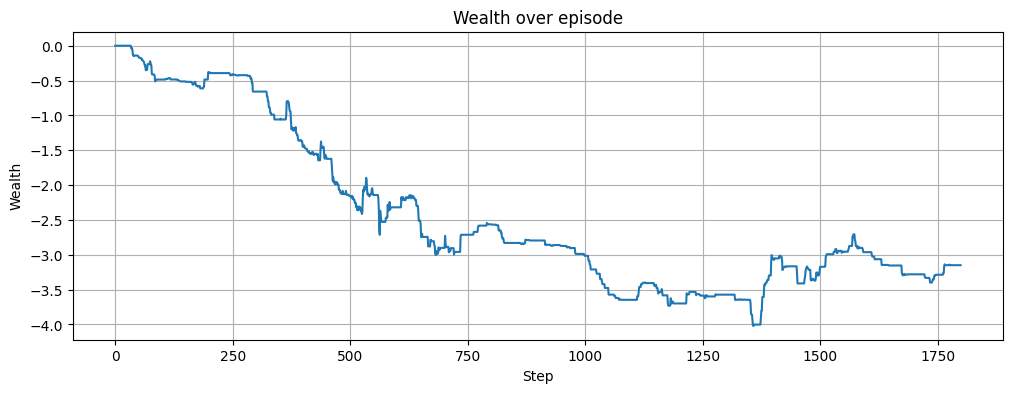

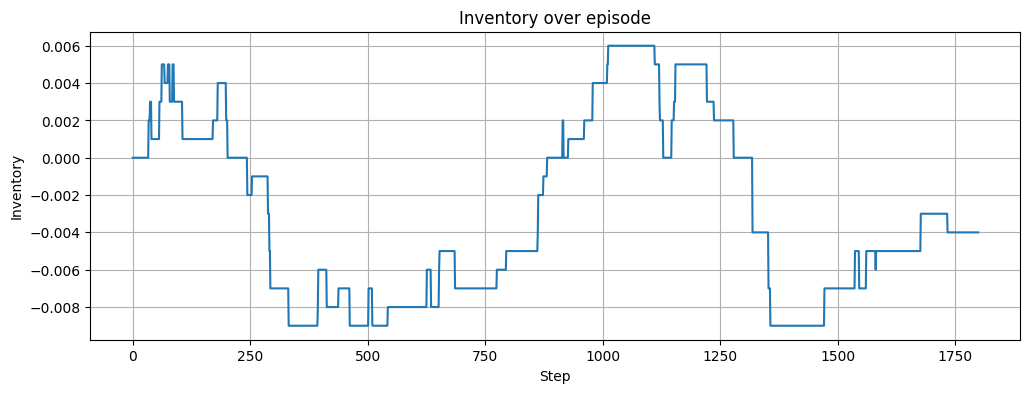

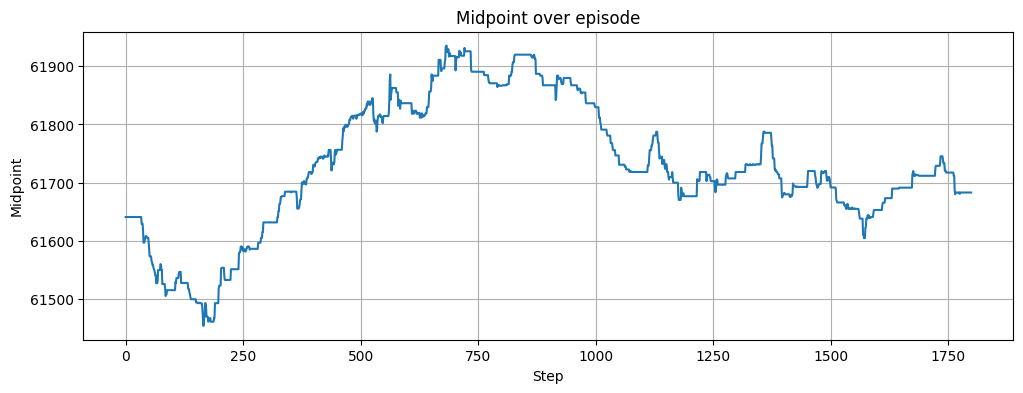

In [21]:
# Robust evaluation cell

from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eval_env = BTCMarketMakingEnv(test_df, **env_kwargs, seed=42)

obs, info = eval_env.reset()
done = False

rewards = []
wealth_path = []
inventory_path = []
midprice_path = []
action_counter = Counter()

while not done:
    action, _ = model.predict(obs, deterministic=True)
    action_tuple = tuple(int(x) for x in np.asarray(action).ravel())
    action_counter[action_tuple] += 1

    obs, reward, terminated, truncated, info = eval_env.step(action)

    rewards.append(float(reward))

    # safe reads from info
    wealth_path.append(float(info.get("wealth", np.nan)))
    inventory_path.append(float(info.get("inventory", np.nan)))

    # midpoint from env dataframe instead of info dict
    idx = min(eval_env.t, len(eval_env.df) - 1)
    if "midpoint" in eval_env.df.columns:
        midprice_path.append(float(eval_env.df.iloc[idx]["midpoint"]))
    else:
        midprice_path.append(np.nan)

    done = terminated or truncated

results = {
    "episode_steps": len(rewards),
    "total_reward": float(np.sum(rewards)),
    "final_wealth": float(wealth_path[-1]) if len(wealth_path) else np.nan,
    "mean_step_reward": float(np.mean(rewards)),
    "std_step_reward": float(np.std(rewards)),
    "mean_abs_inventory": float(np.nanmean(np.abs(inventory_path))),
    "max_abs_inventory": float(np.nanmax(np.abs(inventory_path))),
}

print("\n=== PERFORMANCE ===")
print(pd.Series(results))

print("\n=== TOP ACTIONS ===")
for act, cnt in action_counter.most_common(10):
    print(act, "count =", cnt)

best_action = action_counter.most_common(1)[0][0]
decoded = {
    "bid1_offset": env_kwargs["offset_choices"][best_action[0]],
    "bid1_size":   env_kwargs["size_choices"][best_action[1]],
    "bid2_offset": env_kwargs["offset_choices"][best_action[2]],
    "bid2_size":   env_kwargs["size_choices"][best_action[3]],
    "ask1_offset": env_kwargs["offset_choices"][best_action[4]],
    "ask1_size":   env_kwargs["size_choices"][best_action[5]],
    "ask2_offset": env_kwargs["offset_choices"][best_action[6]],
    "ask2_size":   env_kwargs["size_choices"][best_action[7]],
}
print("\n=== MOST USED STRATEGY ===")
print(pd.Series(decoded))

plt.figure(figsize=(12, 4))
plt.plot(wealth_path)
plt.title("Wealth over episode")
plt.xlabel("Step")
plt.ylabel("Wealth")
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(inventory_path)
plt.title("Inventory over episode")
plt.xlabel("Step")
plt.ylabel("Inventory")
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(midprice_path)
plt.title("Midpoint over episode")
plt.xlabel("Step")
plt.ylabel("Midpoint")
plt.grid()
plt.show()

## DQN implementation with experience replay

This section keeps the existing `BTCMarketMakingEnv` and adds a **Deep Q-Network (DQN)** agent with a **replay buffer** and a **target network**.

Because DQN expects a `Discrete` action space, we wrap the market-making environment and flatten the original `MultiDiscrete` quote action into a single discrete action index.


In [22]:

import random
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset


In [23]:

import itertools
import gymnasium as gym
from gymnasium import spaces

class FlattenedActionWrapper(gym.ActionWrapper):
    """
    Converts the original MultiDiscrete market-making action into one Discrete action
    so it can be used with DQN.

    Original action:
      [bid1_offset, bid1_size, bid2_offset, bid2_size,
       ask1_offset, ask1_size, ask2_offset, ask2_size]
    """
    def __init__(self, env):
        super().__init__(env)
        assert isinstance(env.action_space, spaces.MultiDiscrete), "Expected MultiDiscrete action space"
        self._nvec = np.array(env.action_space.nvec, dtype=np.int64)
        self._action_map = np.array(list(itertools.product(*[range(int(n)) for n in self._nvec])), dtype=np.int64)
        self.action_space = spaces.Discrete(len(self._action_map))
        self.observation_space = env.observation_space

    def action(self, action):
        return self._action_map[int(action)].copy()

    @property
    def action_map(self):
        return self._action_map


In [24]:

from collections import deque

class ReplayBuffer:
    def __init__(self, capacity, obs_dim):
        self.capacity = int(capacity)
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity,), dtype=np.int64)
        self.rewards = np.zeros((capacity,), dtype=np.float32)
        self.dones = np.zeros((capacity,), dtype=np.float32)

        self.ptr = 0
        self.size = 0

    def add(self, obs, action, reward, next_obs, done):
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = int(action)
        self.rewards[self.ptr] = float(reward)
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = float(done)

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size, device):
        idx = np.random.randint(0, self.size, size=batch_size)
        batch = {
            "obs": torch.tensor(self.obs[idx], dtype=torch.float32, device=device),
            "actions": torch.tensor(self.actions[idx], dtype=torch.long, device=device),
            "rewards": torch.tensor(self.rewards[idx], dtype=torch.float32, device=device),
            "next_obs": torch.tensor(self.next_obs[idx], dtype=torch.float32, device=device),
            "dones": torch.tensor(self.dones[idx], dtype=torch.float32, device=device),
        }
        return batch

    def __len__(self):
        return self.size


class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_dims=(256, 256)):
        super().__init__()
        layers = []
        in_dim = obs_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers += [nn.Linear(in_dim, n_actions)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    def __init__(
        self,
        obs_dim,
        n_actions,
        device,
        lr=1e-4,
        gamma=0.99,
        batch_size=256,
        buffer_size=200_000,
        min_buffer_size=5_000,
        target_update_freq=1_000,
        train_freq=4,
        tau=None,  # if set, use soft target updates
    ):
        self.device = device
        self.n_actions = int(n_actions)
        self.gamma = float(gamma)
        self.batch_size = int(batch_size)
        self.min_buffer_size = int(min_buffer_size)
        self.target_update_freq = int(target_update_freq)
        self.train_freq = int(train_freq)
        self.tau = tau

        self.q_net = QNetwork(obs_dim, n_actions).to(device)
        self.target_net = QNetwork(obs_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.replay = ReplayBuffer(buffer_size, obs_dim)
        self.num_updates = 0

    def act(self, obs, epsilon):
        if random.random() < epsilon:
            return random.randrange(self.n_actions)
        obs_t = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_net(obs_t)
            action = int(torch.argmax(q_values, dim=1).item())
        return action

    def update(self):
        if len(self.replay) < self.min_buffer_size:
            return None

        batch = self.replay.sample(self.batch_size, self.device)

        q_values = self.q_net(batch["obs"])
        q_a = q_values.gather(1, batch["actions"].unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            # Double DQN target
            next_actions = self.q_net(batch["next_obs"]).argmax(dim=1, keepdim=True)
            next_q = self.target_net(batch["next_obs"]).gather(1, next_actions).squeeze(1)
            target = batch["rewards"] + self.gamma * (1.0 - batch["dones"]) * next_q

        loss = nn.functional.smooth_l1_loss(q_a, target)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()

        self.num_updates += 1

        if self.tau is not None:
            # soft target update
            with torch.no_grad():
                for p, tp in zip(self.q_net.parameters(), self.target_net.parameters()):
                    tp.data.mul_(1.0 - self.tau).add_(self.tau * p.data)
        elif self.num_updates % self.target_update_freq == 0:
            # hard target update
            self.target_net.load_state_dict(self.q_net.state_dict())

        return float(loss.item())


In [25]:

# Reuse the train/test split already built above if available; otherwise rebuild it.
required_cols = [c for c in feature_cols if c in df.columns]
work_df = df.dropna(subset=required_cols).reset_index(drop=True)

split_idx = int(len(work_df) * 0.8)
train_df = work_df.iloc[:split_idx].reset_index(drop=True)
test_df  = work_df.iloc[split_idx:].reset_index(drop=True)

env_kwargs = dict(
    feature_cols=required_cols,
    lookback=30,
    episode_len=1800,
    tick_size=0.5,
    offset_choices=(0, 1, 2, 4),
    size_choices=(0.0, 0.001, 0.002),
    fee_bps=1.0,
    inventory_limit=0.01,
    gamma_step=None,
)

train_env = FlattenedActionWrapper(BTCMarketMakingEnv(train_df, **env_kwargs, seed=123))
test_env  = FlattenedActionWrapper(BTCMarketMakingEnv(test_df, **env_kwargs, seed=456))

obs_dim = int(np.prod(train_env.observation_space.shape))
n_actions = train_env.action_space.n

print("Observation dimension:", obs_dim)
print("Discrete action count:", n_actions)
print("Original MultiDiscrete nvec:", train_env.env.action_space.nvec)


Observation dimension: 930
Discrete action count: 20736
Original MultiDiscrete nvec: [4 3 4 3 4 3 4 3]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = DQNAgent(
    obs_dim=obs_dim,
    n_actions=n_actions,
    device=device,
    lr=1e-4,
    gamma=0.99,
    batch_size=256,
    buffer_size=200_000,
    min_buffer_size=5_000,
    target_update_freq=1_000,
    train_freq=4,
    tau=None,
)

num_episodes = 60
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay_steps = 50_000

global_step = 0
episode_rewards = []
episode_final_wealth = []
loss_history = []

for episode in range(num_episodes):
    obs, info = train_env.reset()
    done = False
    ep_reward = 0.0
    ep_losses = []

    while not done:
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-global_step / epsilon_decay_steps)
        action = agent.act(obs, epsilon)

        next_obs, reward, terminated, truncated, info = train_env.step(action)
        done = terminated or truncated

        agent.replay.add(obs, action, reward, next_obs, done)

        if global_step % agent.train_freq == 0:
            loss = agent.update()
            if loss is not None:
                ep_losses.append(loss)
                loss_history.append(loss)

        obs = next_obs
        ep_reward += reward
        global_step += 1

    episode_rewards.append(ep_reward)
    episode_final_wealth.append(float(info.get("wealth", np.nan)))

    print(
        f"Episode {episode+1:03d}/{num_episodes} | "
        f"reward={ep_reward:,.4f} | "
        f"final_wealth={episode_final_wealth[-1]:,.4f} | "
        f"epsilon={epsilon:,.4f} | "
        f"avg_loss={np.mean(ep_losses) if ep_losses else np.nan:,.6f}"
    )


In [ ]:

# Evaluate the trained DQN policy
from collections import Counter

obs, info = test_env.reset()
done = False

eval_rewards = []
wealth_path = []
inventory_path = []
midprice_path = []
action_counter = Counter()

while not done:
    action = agent.act(obs, epsilon=0.0)  # greedy
    action_counter[int(action)] += 1

    obs, reward, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated

    eval_rewards.append(float(reward))
    wealth_path.append(float(info.get("wealth", np.nan)))
    inventory_path.append(float(info.get("inventory", np.nan)))

    idx = min(test_env.env.t, len(test_env.env.df) - 1)
    midprice_path.append(float(test_env.env.df.iloc[idx]["midpoint"]))

results = {
    "episode_steps": len(eval_rewards),
    "total_reward": float(np.sum(eval_rewards)),
    "mean_step_reward": float(np.mean(eval_rewards)),
    "final_wealth": float(wealth_path[-1]) if wealth_path else np.nan,
    "final_inventory": float(inventory_path[-1]) if inventory_path else np.nan,
    "unique_actions_used": int(len(action_counter)),
}

results


In [ ]:

plt.figure(figsize=(12, 4))
plt.plot(wealth_path)
plt.title("DQN Evaluation Wealth Path")
plt.xlabel("Step")
plt.ylabel("Wealth")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(inventory_path)
plt.title("DQN Evaluation Inventory Path")
plt.xlabel("Step")
plt.ylabel("Inventory")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(episode_rewards)
plt.title("DQN Training Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

if len(loss_history) > 0:
    plt.figure(figsize=(12, 4))
    plt.plot(loss_history)
    plt.title("DQN Training Loss")
    plt.xlabel("Gradient Step")
    plt.ylabel("Huber Loss")
    plt.show()
